# Bivariate smoothing with coupled latent dynamics

*Author: Stefan T. Radev*

This tutorial introduces time-varying parameter learning with a small bivariate state-space model. The latent target is a two-dimensional parameter trajectory with correlated innovations, and the observations are noisy linear mixtures of the latent state.

The main goal is to distinguish two choices that often get blurred together: filtering versus smoothing, and marginal versus full joint posterior learning. Filtering uses observations only up to the current time; smoothing uses the complete observed sequence (i.e., it's both backward- and forward-looking). Marginal methods learn one time-specific posterior at a time, while joint methods learn a posterior over an entire trajectory and therefore preserve temporal posterior dependence.

With $q$ denoting a learned posterior approximation, the four common targets can be written as:

- Marginal filtering: $q_{\mathrm{MF}}(\theta_{1:T} \mid y_{1:T}) = \prod_{t=1}^T q(\theta_t \mid y_{1:t})$.
- Marginal smoothing: $q_{\mathrm{MS}}(\theta_{1:T} \mid y_{1:T}) = \prod_{t=1}^T q(\theta_t \mid y_{1:T})$.
- Full joint filtering: $q_{\mathrm{JF}}(\theta_{1:T} \mid y_{1:T}) = \prod_{t=1}^T q(\theta_t \mid \theta_{1:t-1}, y_{1:t})$.
- Full joint smoothing: $q_{\mathrm{JS}}(\theta_{1:T} \mid y_{1:T}) = \prod_{t=1}^T q(\theta_t \mid \theta_{1:t-1}, y_{1:T})$.

The marginal products are computationally convenient but intentionally ignore posterior dependence across time.

This notebook demonstrates full joint smoothing using BayesFlow's `AutoregressiveApproximator`, which samples complete latent trajectories conditional on observed sequences. It uses the default transformer encoder and recurrent decoder (T → R), then finishes with a small learned end-of-sequence (EOS) example for an unknown number of parameter packets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import bayesflow as bf
import keras

keras.utils.set_random_seed(2027)
np.set_printoptions(suppress=True)

INFO:bayesflow:Using backend 'jax'


## Generative model

We use a two-dimensional latent random walk with correlated innovations,

$$
\theta_1 \sim \mathcal{N}(0, \sigma_0^2 I),\qquad
\theta_t = \theta_{t-1} + L\eta_t,\qquad
\eta_t \sim \mathcal{N}(0, I_2),
$$

observed through noisy mixed bivariate measurements,

$$
y_t = H\theta_t + \sigma_y\epsilon_t,\qquad
\epsilon_t \sim \mathcal{N}(0, I_2).
$$

The simulator is deliberately simple, but it is not a direct-measurement toy. The Cholesky factor $L$ couples the two latent coordinates through correlated state innovations, so shocks to one parameter dimension tend to move with shocks to the other. The observation matrix $H$ mixes the latent coordinates before noise is added, so each observed channel contains partial information about both latent dimensions.

If we want a more interesting follow-up example, the smallest useful complication would be to let the transition scale, observation scale, or mixing matrix vary across simulated datasets, or to add a weak nonlinear drift. That would create a richer posterior geometry.

The inference target is the complete trajectory $\theta_{1:T}$, and the condition is the complete observed sequence $\{(t, y_t)\}_{1:T}$.

In [2]:
class StateSpaceSimulator:
    """Two-dimensional random walk observed through a fixed linear mixing matrix."""

    def __init__(self, num_steps=80, initial_sd=0.50, step_sd=0.08, observation_sd=0.30, seed=2027):
        self.num_steps = num_steps
        self.initial_sd = initial_sd
        self.observation_sd = observation_sd
        self.rng = np.random.default_rng(seed)
        self.time = np.linspace(0.0, 1.0, num_steps, dtype="float32")

        self.innovation_cholesky = step_sd * np.array(
            [
                [1.00, 0.00],
                [0.60, 0.80],
            ]
        )
        self.observation_matrix = np.array(
            [
                [1.00, 0.35],
                [-0.25, 0.90],
            ]
        )
        self.unmixing_matrix = np.linalg.inv(self.observation_matrix)

    def sample(self, batch_shape):
        if isinstance(batch_shape, int):
            batch_shape = (batch_shape,)

        batch_shape = tuple(batch_shape)
        batch_size = np.prod(batch_shape)

        initial = self.rng.normal(scale=self.initial_sd, size=(batch_size, 1, 2))
        white_noise = self.rng.normal(size=(batch_size, self.num_steps - 1, 2))
        increments = white_noise @ self.innovation_cholesky.T
        theta = np.concatenate([initial, initial + np.cumsum(increments, axis=1)], axis=1)
        y = theta @ self.observation_matrix.T + self.rng.normal(scale=self.observation_sd, size=theta.shape)

        sequence_shape = batch_shape + (self.num_steps, 2)
        time_shape = batch_shape + (self.num_steps, 1)
        time = np.broadcast_to(self.time[None, :, None], time_shape)

        return {
            "time": time,
            "y": y.reshape(sequence_shape),
            "theta": theta.reshape(sequence_shape),
        }


simulator = StateSpaceSimulator(num_steps=80, seed=2027)
prior_draws = simulator.sample(8)
{k: v.shape for k, v in prior_draws.items()}

{'time': (8, 80, 1), 'y': (8, 80, 2), 'theta': (8, 80, 2)}

## Prior predictive checks

Each panel shows one simulated bivariate trajectory. Solid lines are the latent trajectory. Faint points are the noisy mixed observations projected back onto the latent coordinate system.

Text(0.02, 0.5, 'Parameter value')

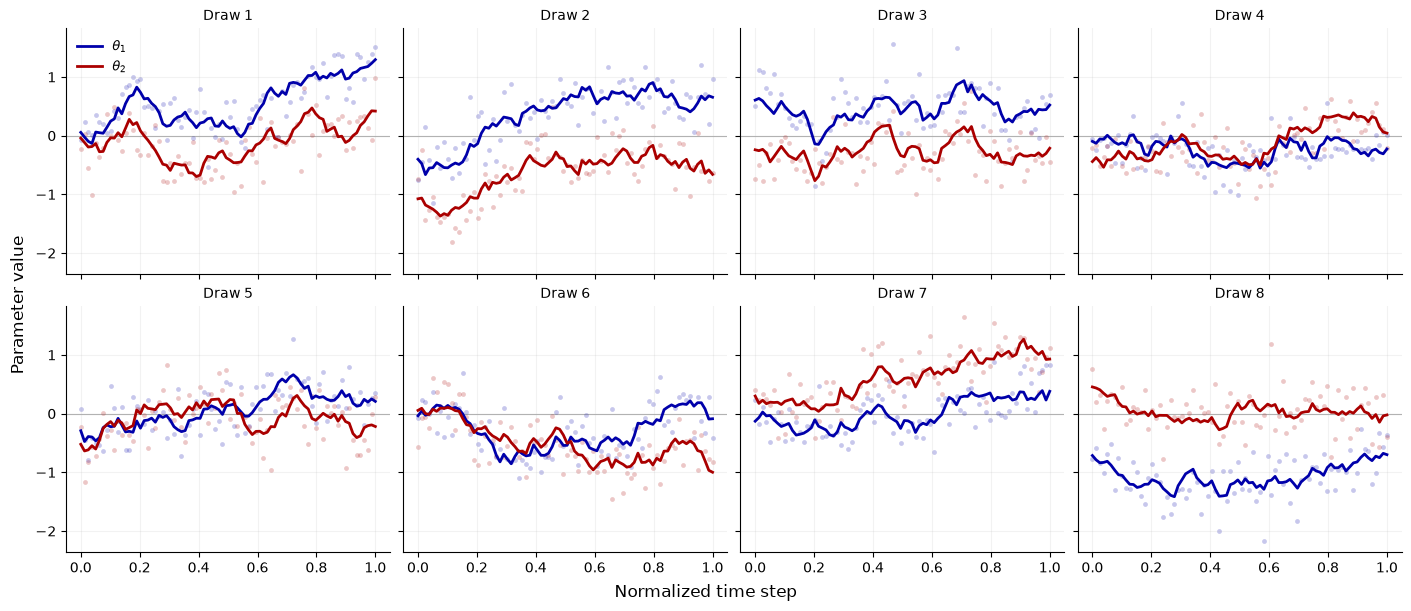

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True, constrained_layout=True)
colors = ["#0000AA", "#AA0000"]

for i, ax in enumerate(axes.flat):
    time = prior_draws["time"][i, :, 0]
    theta = prior_draws["theta"][i]
    y = prior_draws["y"][i]
    unmixed_y = y @ simulator.unmixing_matrix.T

    for dim, color in enumerate(colors):
        ax.scatter(time, unmixed_y[:, dim], color=color, s=12, alpha=0.22, linewidth=0)
        ax.plot(time, theta[:, dim], color=color, linewidth=2, label=rf"$\theta_{dim + 1}$")

    ax.axhline(0.0, color="0.7", linewidth=0.8, zorder=0)
    ax.set_title(f"Draw {i + 1}", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.16)

axes.flat[0].legend(frameon=False, fontsize=9)
fig.supxlabel("Normalized time step")
fig.supylabel("Parameter value")

## Adapter and data

The approximator expects two sequence tensors:

- `summary_variables`: what we condition on, here `(t, y_{t,1}, y_{t,2})`.
- `inference_variables`: what we infer, here `(theta_{t,1}, theta_{t,2})`. Note, that the intrinsic dimension of the problem is $\textrm{dim}(\theta_t) = 2$, as the inference network learns to sample one time point at a time.

The rest proceeds like bayesflow as usual.

In [4]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series(["time", "y", "theta"])
    .concatenate(["time", "y"], into="summary_variables")
    .concatenate(["theta"], into="inference_variables")
)

num_batches = 100
num_val = 256
batch_size = 64

data_val = simulator.sample(num_val)

train_dataset = bf.OnlineDataset(
    simulator,
    batch_size=batch_size,
    num_batches=num_batches,
    adapter=adapter,
    workers=2,
)
val_dataset = bf.OfflineDataset(data_val, batch_size=batch_size, adapter=adapter, shuffle=False)

adapted_preview = adapter(simulator.sample(2))
adapted_preview["summary_variables"].shape, adapted_preview["inference_variables"].shape

((2, 80, 3), (2, 80, 2))

## Networks

For an `AutoregressiveApproximator`, the sequence model has two parts: an encoder for the observed sequence and a decoder for the target trajectory. Users have four basic building blocks to mix and match:

- Encoder: `bf.networks.RecurrentNetwork(return_sequences=True)` or `bf.networks.TimeSeriesTransformer(return_sequences=True)`.
- Decoder: `bf.networks.RecurrentDecoder()` or `bf.networks.TransformerDecoder()`.

Custom encoder/decoder pairs are also supported. The default pair is **T → R**: `TimeSeriesTransformer(return_sequences=True)` and `RecurrentDecoder()`. We use these defaults below by omitting both network arguments. The encoder returns one condition per target time point rather than a single global summary. The inference network is a small depth-2 spline coupling flow.

The division of labor works like this:

- The **encoder** reads the complete noisy sequence and returns a sequence of representations of the same length. Each element in this sequence represents a complete summary of the sequence. 
- The **decoder** represents the "memory" of the inference network, conditioning the bivariate latent trajectory autoregressively. During training it uses shifted true targets (teacher forcing); during sampling it consumes previous generated packets. Different posterior draws are generated in parallel, while positions within each trajectory are decoded sequentially.

In [ ]:
inference_network = bf.networks.CouplingFlow(transform="spline", depth=2, subnet_kwargs={"dropout": 0.0})

approximator = bf.AutoregressiveApproximator(
    inference_network=inference_network,
    adapter=adapter,
    standardize="all"
)

## Training

The settings below are small enough for a tutorial notebook. Increase `num_batches` and `epochs` if you want cleaner posterior bands. We use `Adam` since we are in an online (i.e., infinite data) training regime.

In [ ]:
epochs = 100

# Cosine decay is crucial for performance
optimizer = keras.optimizers.Adam(
    learning_rate=keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-3,
        decay_steps=epochs * num_batches,
        alpha=0.1
    )
)

approximator.compile(optimizer=optimizer)

Validation is optional for online training, but lets us compare training and validation losses.

In [ ]:
history = approximator.fit(
    dataset=train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    verbose=2,
)

The plot compares training and validation losses. Convergence alone does not establish posterior calibration; we also inspect fresh posterior samples below.

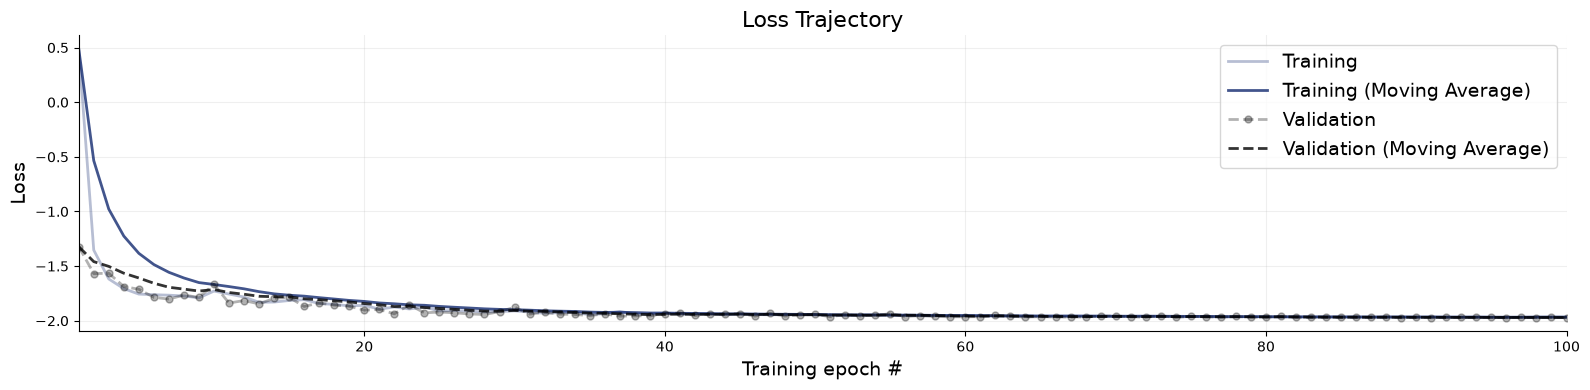

In [8]:
fig = bf.diagnostics.loss(history)

## Posterior smoothing samples

Once training has completed, we can easily sample bivariate trajectories from the learned joint smoother.

In [9]:
num_test = 5

test_data = simulator.sample(num_test)

posterior = approximator.sample(
    conditions={"time": test_data["time"], "y": test_data["y"]},
    num_samples=1000,
    seed=2028,
)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

/home/radevs/anaconda3/envs/bfjax/lib/python3.12/site-packages/keras/src/backend/jax/core.py:401: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.asarray(x, dtype=dtype)


In the plot below, different test datasets are shown in the columns and inferred parameters (latent trajectories) in the rows. The posterior bands are pointwise credible intervals for the parameters per time point. The black line with markers is the ground-truth latent trajectory.

Text(0.02, 0.5, 'Latent value')

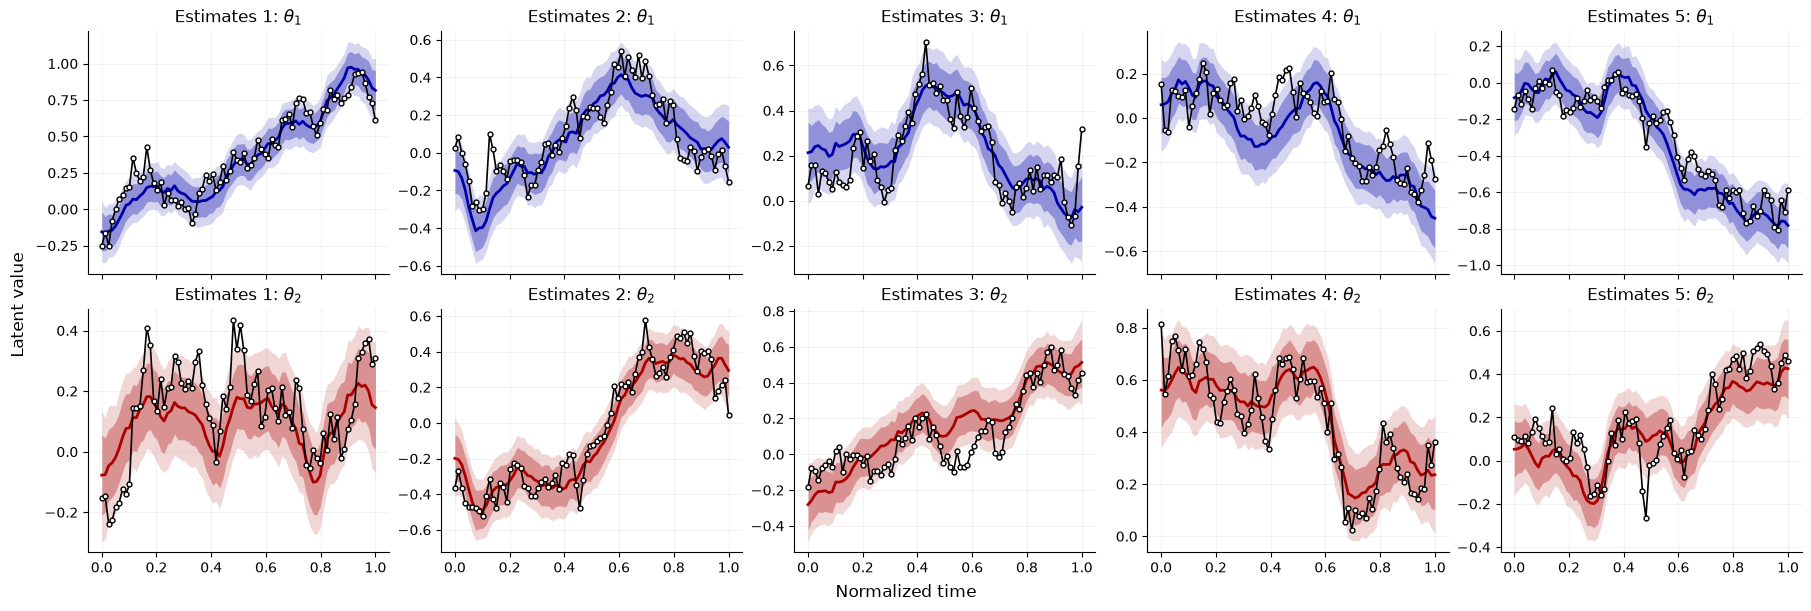

In [10]:
fig, axes = plt.subplots(2, num_test, figsize=(18, 6), sharex=True, constrained_layout=True)
colors = ["#0000AA", "#AA0000"]


def plot_smoother(ax, draws, truth, time, title, color):
    lo89, lo68, med, hi68, hi89 = np.quantile(draws, [0.055, 0.16, 0.5, 0.84, 0.945], axis=0)

    ax.fill_between(time, lo89, hi89, color=color, alpha=0.16, linewidth=0)
    ax.fill_between(time, lo68, hi68, color=color, alpha=0.32, linewidth=0)
    ax.plot(time, med, color=color, linewidth=2)
    ax.plot(
        time,
        truth,
        color="black",
        marker="o",
        markersize=3.5,
        linewidth=1.2,
        markerfacecolor="white",
        markeredgewidth=1,
    )
    ax.set_title(title, fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.16)


for i in range(num_test):
    time = test_data["time"][i, :, 0]

    for dim, color in enumerate(colors):
        plot_smoother(
            axes[dim, i],
            posterior["theta"][i, :, :, dim],
            test_data["theta"][i, :, dim],
            time,
            rf"Estimates {i + 1}: $\theta_{dim + 1}$",
            color,
        )


fig.supxlabel("Normalized time")
fig.supylabel("Latent value")

## Unknown packet counts with learned EOS

The smoother above has a known trajectory length. Some problems may have an unknown number of parameter packets. Padding alone does not teach a continuous density to generate an exact stopping token: enable a learned EOS decision with `eos_value`.

In this small, separate example, $N$ is uniform on $\{0,1,2\}$, each two-dimensional packet has a standard normal prior, and $x = \sum_{j=1}^N \theta_{j,1} + \epsilon$, with $\epsilon \sim \mathcal N(0,1)$. We infer both the count and the packets.

Set `eos_value=-1.0` to reserve the whole vector `[-1, -1]` as EOS/padding. Each training sequence contains its packets, followed by EOS and any remaining padding. Alternatively, supply `inference_mask`: true entries are packets, the first false entry is EOS, and later false entries are padding. Still set `eos_value` to enable learned stopping; the mask overrides sentinel detection.

The default recurrent decoder needs aligned conditions. We repeat only the observed $x$ across three slots, including room for EOS—not the unknown count. No `summary_variables` or explicit encoder/decoder networks are needed.

In [11]:
EOS = -1.0
max_packets = 2
max_horizon = max_packets + 1  # Includes room for EOS, not a known sample length.


class PacketSimulator:
    def __init__(self, seed=42):
        self.rng = np.random.default_rng(seed)

    def sample(self, batch_size):
        counts = self.rng.integers(0, max_packets + 1, size=batch_size)
        packets = self.rng.normal(size=(batch_size, max_packets, 2)).astype("float32")
        valid = np.arange(max_packets)[None] < counts[:, None]
        x = np.where(valid, packets[..., 0], 0.0).sum(axis=1)
        x += self.rng.normal(size=batch_size)
        targets = np.full((batch_size, max_horizon, 2), EOS, dtype="float32")
        targets[:, :max_packets] = np.where(valid[..., None], packets, EOS)
        conditions = np.repeat(x[:, None, None], max_horizon, axis=1).astype("float32")
        return {
            "inference_variables": targets,
            "inference_conditions": conditions,
        }


packet_simulator = PacketSimulator()
print("Examples of packet rows followed by EOS/padding:")
print(packet_simulator.sample(2)["inference_variables"])

Examples of packet rows followed by EOS/padding:
[[[-1.         -1.        ]
  [-1.         -1.        ]
  [-1.         -1.        ]]

 [[-1.3021795   0.1278404 ]
  [-0.3162426  -0.01680116]
  [-1.         -1.        ]]]


In [ ]:
# You can also play with any generative head
approximator = bf.AutoregressiveApproximator(
    inference_network=bf.networks.CouplingFlow(
        transform="spline",
        depth=2,
        subnet_kwargs={"dropout": 0.0},
    ),
    eos_value=EOS
)

# Online data set as usual
dataset = bf.OnlineDataset(
    packet_simulator,
    batch_size=64,
    num_batches=40,
    adapter=approximator.adapter,
    workers=2
)

# Again, cosine decay is crucial for performance
optimizer = keras.optimizers.Adam(
    learning_rate=keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-3, 
        decay_steps=40 * 40, 
        alpha=0.1
    )
)
approximator.compile(optimizer=optimizer)
eos_history = approximator.fit(dataset=dataset, epochs=40, verbose=2)

### Sample without supplying a count

`max_horizon` caps decoding slots, including EOS; it does not supply a packet count. Draws run in parallel and stop independently. The returned arrays stay rectangular: `_mask` selects real packets, `_lengths` gives their counts, and `_truncated` flags draws that reached the cap without EOS. Use the mask to recover variable-length packets. Sampling conditions contain only observations.

In [ ]:
observed_x = np.array([0.0, 2.0], dtype="float32")
packet_posterior = approximator.sample(
    conditions={"inference_conditions": np.repeat(observed_x[:, None, None], max_horizon, axis=1)},
    num_samples=5000,
    max_horizon=max_horizon,
    seed=44,
)
print({key: value.shape for key, value in packet_posterior.items()})

for index in range(5):
    values = packet_posterior["inference_variables"][1, index]
    mask = packet_posterior["_mask"][1, index]
    print(f"Draw {index + 1}: {packet_posterior['_lengths'][1, index]} packets", values[mask])

print("Truncation rates:", packet_posterior["_truncated"].mean(axis=1))

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

{'inference_variables': (2, 5000, 3, 2), '_mask': (2, 5000, 3), '_lengths': (2, 5000), '_truncated': (2, 5000)}
Draw 1: 1 packets [[2.1081667 0.3246381]]
Draw 2: 1 packets [[ 1.5330967 -1.7252342]]
Draw 3: 1 packets [[ 1.6807446 -1.8860215]]
Draw 4: 2 packets [[ 0.6212101  -1.1979678 ]
 [-0.08337147  0.12617444]]
Draw 5: 2 packets [[ 0.2313832 -0.8480871]
 [ 1.0976343 -0.2078175]]
Truncation rates: [0.     0.0002]


For this small problem we can verify the learned count distribution analytically: $x\mid N=n \sim \mathcal N(0,n+1)$, so $p(N=n\mid x) \propto (n+1)^{-1/2}\exp[-x^2/(2(n+1))]$. The bars compare the sampled counts to this exact posterior on fresh observations. This is a single-seed demonstration, not a calibration study.

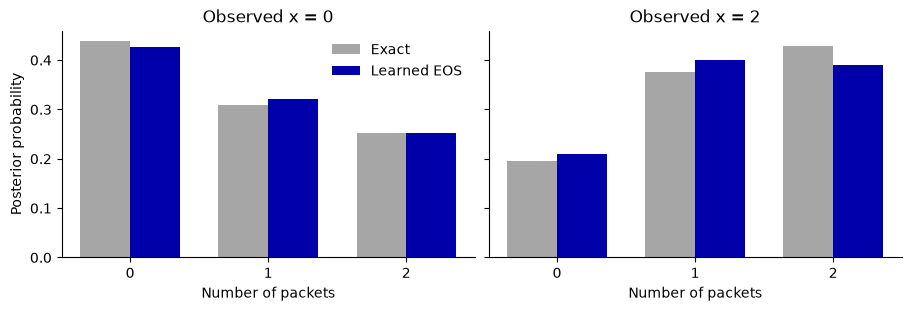

In [ ]:
counts = np.arange(max_packets + 1)
weights = np.exp(-(observed_x[:, None] ** 2) / (2 * (counts + 1))) / np.sqrt(counts + 1)
exact_count_posterior = weights / weights.sum(axis=1, keepdims=True)
sampled_count_posterior = np.stack([(packet_posterior["_lengths"] == n).mean(axis=1) for n in counts], axis=1)

fig, axes = plt.subplots(1, len(observed_x), figsize=(9, 3), sharey=True, constrained_layout=True)

for i, ax in enumerate(axes):
    ax.bar(counts - 0.18, exact_count_posterior[i], width=0.36, label="Exact", color="0.65")
    ax.bar(counts + 0.18, sampled_count_posterior[i], width=0.36, label="Learned EOS", color="#0000AA")
    ax.set(title=f"Observed x = {observed_x[i]:g}", xlabel="Number of packets", xticks=counts)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Posterior probability")
axes[0].legend(frameon=False)

## Next steps

More rigorous diagnostics would be needed to ascertain the fidelity of the autoregressive approximator. These could feature various Bayesian metrics over time, e.g., calibration error, NRMSE, etc. Feel free to

- Switch from online to offline training and explore how performance changes under a much smaller simulation budget.
- Make the generative model more challenging by introducing nonlinear dynamics or non-Gaussian noise.
- Experiment with different encoder and decoder architectures and compare their impact on inference quality.